In [6]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import warnings
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

RAW_DATA_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
PROJECT_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
EARTH_RADIUS_METERS = 6371008.8

In [2]:
def parse_fused_data():
    rest_files = glob.glob(os.path.join(RAW_DATA_DIR, "*RestPoints*.tab"))
    path_files = glob.glob(os.path.join(RAW_DATA_DIR, "*Paths*.tab"))
    
    # 1. Parse Rest Data (Nodes)
    raw_rest = pd.read_csv(rest_files[0], sep="\t", low_memory=False)
    df_rest = pd.DataFrame({
        "lat": pd.to_numeric(raw_rest["Lat"], errors="coerce"),
        "lon": pd.to_numeric(raw_rest["Lon"], errors="coerce"),
        "building": raw_rest["Building_Name"].astype(str) if "Building_Name" in raw_rest.columns else "Unknown",
    }).dropna()
    df_rest = df_rest[(df_rest["lat"].between(51.070, 51.090)) & (df_rest["lon"].between(-114.150, -114.110))]
    df_rest = df_rest[~df_rest["building"].isin(["Outdoors", "Unknown", "BETWEEN TERMS"])].copy()

    # 2. Parse Path Data (Edges)
    raw_path = pd.read_csv(path_files[0], sep="\t", low_memory=False)
    df_path = pd.DataFrame({
        "path_id": pd.to_numeric(raw_path["Path_ID"], errors="coerce"),
        "point_id": pd.to_numeric(raw_path["Path_Point_ID"], errors="coerce"),
        "lat": pd.to_numeric(raw_path["Lat"], errors="coerce"),
        "lon": pd.to_numeric(raw_path["Lon"], errors="coerce")
    }).dropna()
    df_path = df_path[(df_path["lat"].between(51.070, 51.090)) & (df_path["lon"].between(-114.150, -114.110))]

    return df_rest, df_path

df_rest, df_path = parse_fused_data()
print(f"Loaded {len(df_rest)} Rest Points and {df_path['path_id'].nunique()} unique walking journeys.")

Loaded 51482 Rest Points and 5531 unique walking journeys.


In [3]:
print("--- Calculating Hub Centroids from Rest Data ---")
# Run a strict DBSCAN to find the definitive center of each building hub
coords = np.radians(df_rest[["lat", "lon"]].values)
db = DBSCAN(eps=12.0 / EARTH_RADIUS_METERS, min_samples=60, metric="haversine")
df_rest["cluster"] = db.fit_predict(coords)

hub_centroids = {}
for c_id in sorted(df_rest["cluster"].unique()):
    if c_id == -1: 
        continue
    mask = df_rest["cluster"] == c_id
    hub_centroids[c_id] = {
        "lat": df_rest.loc[mask, "lat"].mean(),
        "lon": df_rest.loc[mask, "lon"].mean(),
        "weight": mask.sum() # How popular the hub is
    }

print(f"Established {len(hub_centroids)} physical hubs for the transit network.")

--- Calculating Hub Centroids from Rest Data ---
Established 58 physical hubs for the transit network.


In [4]:
print("--- Mapping Paths to O-D Transition Flow ---")
# Extract just the Start (Origin) and End (Destination) of every path
starts = df_path.sort_values("point_id").groupby("path_id").first().reset_index()
ends = df_path.sort_values("point_id").groupby("path_id").last().reset_index()

# Build a spatial tree of our Hubs
hub_ids = list(hub_centroids.keys())
hub_coords = np.radians([[hub_centroids[cid]["lat"], hub_centroids[cid]["lon"]] for cid in hub_ids])
tree = BallTree(hub_coords, metric="haversine")

# Find the nearest Hub to every Path's start and end point
start_rads = np.radians(starts[["lat", "lon"]].values)
end_rads = np.radians(ends[["lat", "lon"]].values)

dist_start, ind_start = tree.query(start_rads, k=1)
dist_end, ind_end = tree.query(end_rads, k=1)

# Compile the transitions (filtering out paths that start and end at the exact same hub)
transitions = pd.DataFrame({
    "origin_hub": [hub_ids[i[0]] for i in ind_start],
    "dest_hub": [hub_ids[i[0]] for i in ind_end],
    "origin_dist_m": dist_start.flatten() * EARTH_RADIUS_METERS,
    "dest_dist_m": dist_end.flatten() * EARTH_RADIUS_METERS
})

# Filter out massive anomalies (e.g., path started 500m away from any known hub)
transitions = transitions[(transitions["origin_dist_m"] < 50) & (transitions["dest_dist_m"] < 50)]
valid_transitions = transitions[transitions["origin_hub"] != transitions["dest_hub"]]

# Count how many times each specific route was taken
route_counts = valid_transitions.groupby(["origin_hub", "dest_hub"]).size().reset_index(name="traffic")
print(f"Mapped {len(route_counts)} distinct transit corridors between hubs.")

--- Mapping Paths to O-D Transition Flow ---
Mapped 1043 distinct transit corridors between hubs.


--- Visualizing the Origin-Destination Network ---


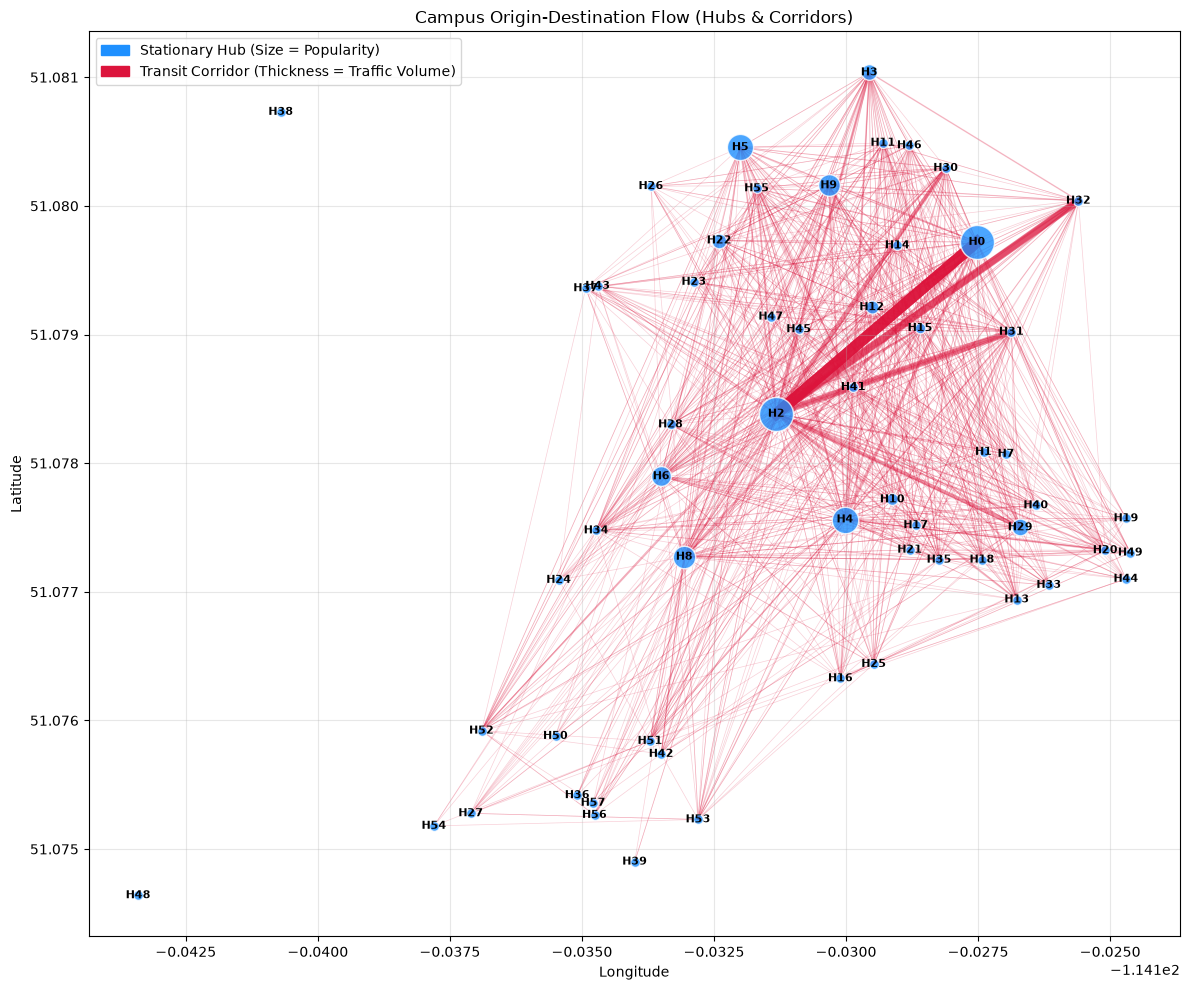

In [7]:
print("--- Visualizing the Origin-Destination Network ---")
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot the Hubs (Nodes)
for c_id, info in hub_centroids.items():
    # Size the hub based on its popularity
    node_size = np.clip(info["weight"] / 10, 50, 600)
    ax.scatter(info["lon"], info["lat"], c="dodgerblue", s=node_size, alpha=0.8, edgecolors="white", zorder=3)
    ax.text(info["lon"], info["lat"], f"H{c_id}", fontsize=8, ha='center', va='center', weight='bold', color="black", zorder=4)

# 2. Draw the Transit Corridors (Edges)
max_traffic = route_counts["traffic"].max()
for _, row in route_counts.iterrows():
    orig = hub_centroids[row["origin_hub"]]
    dest = hub_centroids[row["dest_hub"]]
    
    # Line thickness and opacity based on how many people take this route
    traffic_weight = row["traffic"]
    line_width = np.clip((traffic_weight / max_traffic) * 10, 0.5, 8.0)
    alpha_val = np.clip((traffic_weight / max_traffic), 0.2, 0.8)
    
    ax.plot([orig["lon"], dest["lon"]], 
            [orig["lat"], dest["lat"]], 
            c="crimson", linewidth=line_width, alpha=alpha_val, zorder=1)

ax.set_title("Campus Origin-Destination Flow (Hubs & Corridors)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add a simple legend explaining the visual grammar
handles = [
    mpatches.Patch(color="dodgerblue", label="Stationary Hub (Size = Popularity)"),
    mpatches.Patch(color="crimson", label="Transit Corridor (Thickness = Traffic Volume)")
]
ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.grid(True, alpha=0.3, zorder=0)
plt.tight_layout()
out_path = os.path.join(FIG_DIR, "combined_od_network.png")
fig.savefig(out_path, dpi=300)
plt.show()

In [8]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import warnings
warnings.filterwarnings('ignore')

RAW_DATA_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
PROJECT_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/lubesh")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
EARTH_RADIUS_METERS = 6371008.8

def get_safe_filename(title):
    return "".join([c if c.isalnum() else "_" for c in title]).replace("__", "_").lower()

In [9]:
# 1. Parse Rest Data (No Outdoors) and extract Building Hubs
rest_files = glob.glob(os.path.join(RAW_DATA_DIR, "*RestPoints*.tab"))
df_rest = pd.read_csv(rest_files[0], sep="\t", low_memory=False)
df_rest = pd.DataFrame({
    "lat": pd.to_numeric(df_rest["Lat"], errors="coerce"),
    "lon": pd.to_numeric(df_rest["Lon"], errors="coerce"),
    "building": df_rest["Building_Name"].astype(str)
}).dropna()
df_rest = df_rest[(df_rest["lat"].between(51.070, 51.090)) & (df_rest["lon"].between(-114.150, -114.110))]
df_rest = df_rest[~df_rest["building"].isin(["Outdoors", "Unknown", "BETWEEN TERMS"])].copy()

# Run strict DBSCAN to get distinct hubs
coords = np.radians(df_rest[["lat", "lon"]].values)
db = DBSCAN(eps=10.0 / EARTH_RADIUS_METERS, min_samples=60, metric="haversine")
df_rest["hub_id"] = db.fit_predict(coords)

# Calculate the exact center (centroid) of each discovered hub
hubs = []
for h_id in df_rest["hub_id"].unique():
    if h_id == -1: continue
    mask = df_rest["hub_id"] == h_id
    hubs.append({
        "hub_id": h_id,
        "name": df_rest.loc[mask, "building"].mode()[0],
        "lat": df_rest.loc[mask, "lat"].mean(),
        "lon": df_rest.loc[mask, "lon"].mean()
    })
df_hubs = pd.DataFrame(hubs)

# 2. Parse Path Data grouped by Path_ID
path_files = glob.glob(os.path.join(RAW_DATA_DIR, "*Paths*.tab"))
raw_path = pd.read_csv(path_files[0], sep="\t", low_memory=False)
df_path = pd.DataFrame({
    "path_id": raw_path["Path_ID"],
    "timestamp": pd.to_datetime(raw_path["Loct"], format="%d-%b-%Y %I:%M:%S %p", errors="coerce"),
    "lat": pd.to_numeric(raw_path["Lat"], errors="coerce"),
    "lon": pd.to_numeric(raw_path["Lon"], errors="coerce"),
    "speed": pd.to_numeric(raw_path["Speed"], errors="coerce"),
    "snow_cm": pd.to_numeric(raw_path["Snow_cm"], errors="coerce")
}).dropna(subset=["timestamp", "lat", "lon"])
df_path["minute"] = df_path["timestamp"].dt.minute

print(f"Extracted {len(df_hubs)} distinct Rest Hubs for O-D mapping.")

Extracted 76 distinct Rest Hubs for O-D mapping.


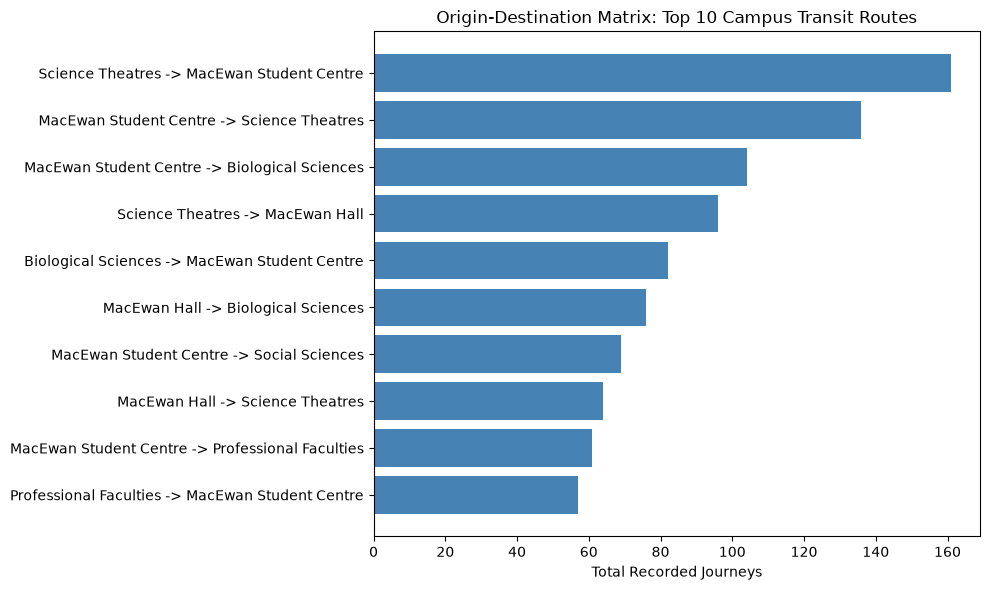

In [10]:
# Extract the first (Origin) and last (Destination) point of every path
paths_grouped = df_path.sort_values(["path_id", "timestamp"]).groupby("path_id")
df_od = paths_grouped.agg(
    o_lat=("lat", "first"), o_lon=("lon", "first"),
    d_lat=("lat", "last"), d_lon=("lon", "last"),
    duration_sec=("timestamp", lambda x: (x.iloc[-1] - x.iloc[0]).total_seconds()),
    snow_cm=("snow_cm", "mean")
).reset_index()
df_od = df_od[df_od["duration_sec"] > 0] # Filter out glitches

# Map Origins and Destinations to the nearest Rest Hub
tree = BallTree(np.radians(df_hubs[["lat", "lon"]].values), metric="haversine")
o_idx = tree.query(np.radians(df_od[["o_lat", "o_lon"]].values), k=1)[1].flatten()
d_idx = tree.query(np.radians(df_od[["d_lat", "d_lon"]].values), k=1)[1].flatten()

df_od["origin_hub"] = df_hubs.iloc[o_idx]["name"].values
df_od["dest_hub"] = df_hubs.iloc[d_idx]["name"].values
df_od = df_od[df_od["origin_hub"] != df_od["dest_hub"]] # Ignore circular paths

# Plot Top 10 Transit Flows
top_flows = df_od.groupby(["origin_hub", "dest_hub"]).size().reset_index(name="trips")
top_flows = top_flows.sort_values("trips", ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_flows["origin_hub"] + " -> " + top_flows["dest_hub"], top_flows["trips"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Origin-Destination Matrix: Top 10 Campus Transit Routes")
plt.xlabel("Total Recorded Journeys")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "od_matrix_flows.png"), dpi=300)
plt.show()

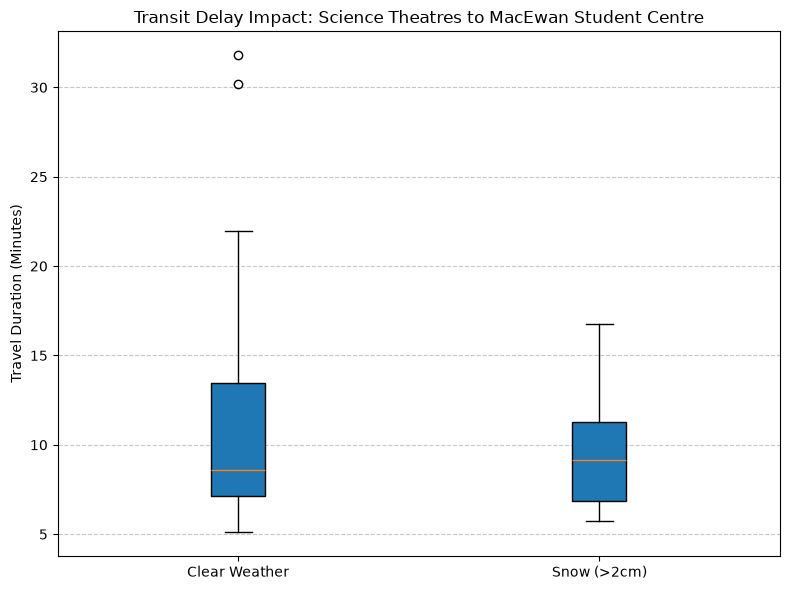

In [12]:
# Compare transit times on the most popular route based on weather
top_route = top_flows.iloc[0]
route_paths = df_od[(df_od["origin_hub"] == top_route["origin_hub"]) & (df_od["dest_hub"] == top_route["dest_hub"])]

clear_days = route_paths[route_paths["snow_cm"] == 0]["duration_sec"] / 60
snow_days = route_paths[route_paths["snow_cm"] > 2]["duration_sec"] / 60

plt.figure(figsize=(8, 6))
# Removed the deprecated 'labels' parameter
plt.boxplot([clear_days.dropna(), snow_days.dropna()], patch_artist=True)
# Apply the labels explicitly using xticks
plt.xticks([1, 2], ["Clear Weather", "Snow (>2cm)"])

plt.title(f"Transit Delay Impact: {top_route['origin_hub']} to {top_route['dest_hub']}")
plt.ylabel("Travel Duration (Minutes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "od_transit_delays.png"), dpi=300)
plt.show()

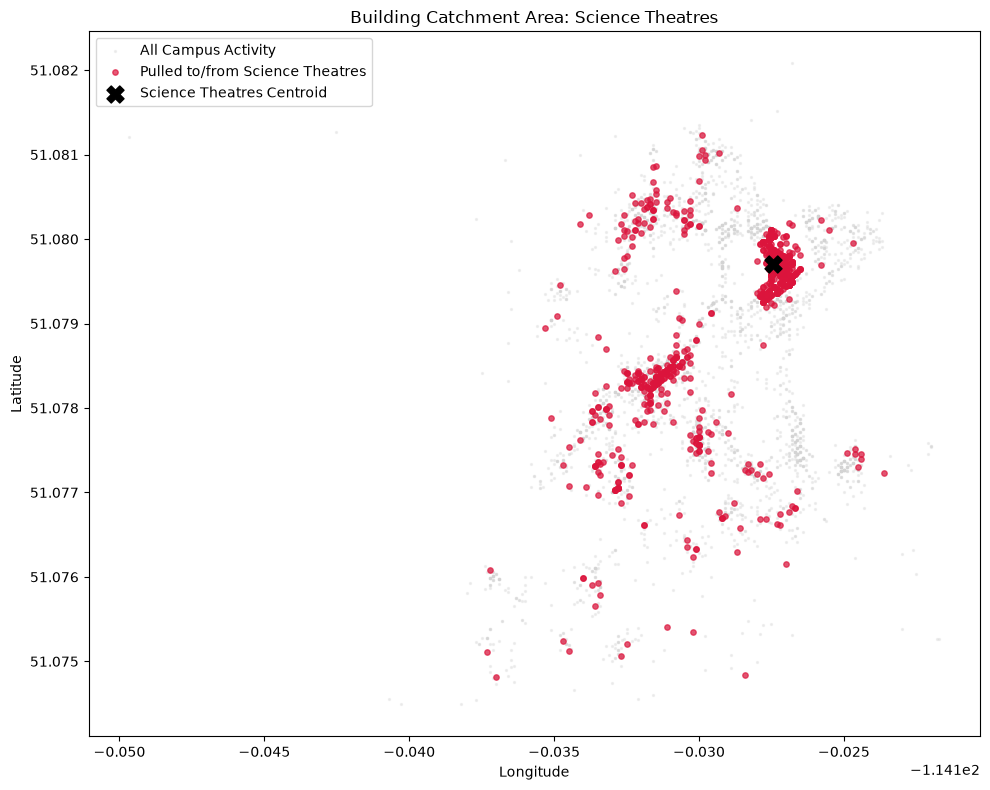

In [13]:
# Visualize the magnetic pull of the busiest hub
busiest_hub_name = top_flows.iloc[0]["origin_hub"]
hub_data = df_hubs[df_hubs["name"] == busiest_hub_name].iloc[0]

# Find all paths that originate or terminate at this hub
catchment_paths = df_od[(df_od["origin_hub"] == busiest_hub_name) | (df_od["dest_hub"] == busiest_hub_name)]

plt.figure(figsize=(10, 8))
plt.scatter(df_od["o_lon"], df_od["o_lat"], c="lightgrey", s=2, alpha=0.3, label="All Campus Activity")

# Plot points that are physically pulled to/from this hub
plt.scatter(catchment_paths["o_lon"], catchment_paths["o_lat"], c="crimson", s=15, alpha=0.7, label=f"Pulled to/from {busiest_hub_name}")
plt.scatter(hub_data["lon"], hub_data["lat"], c="black", marker="X", s=150, label=f"{busiest_hub_name} Centroid")

plt.title(f"Building Catchment Area: {busiest_hub_name}")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "od_catchment_area.png"), dpi=300)
plt.show()

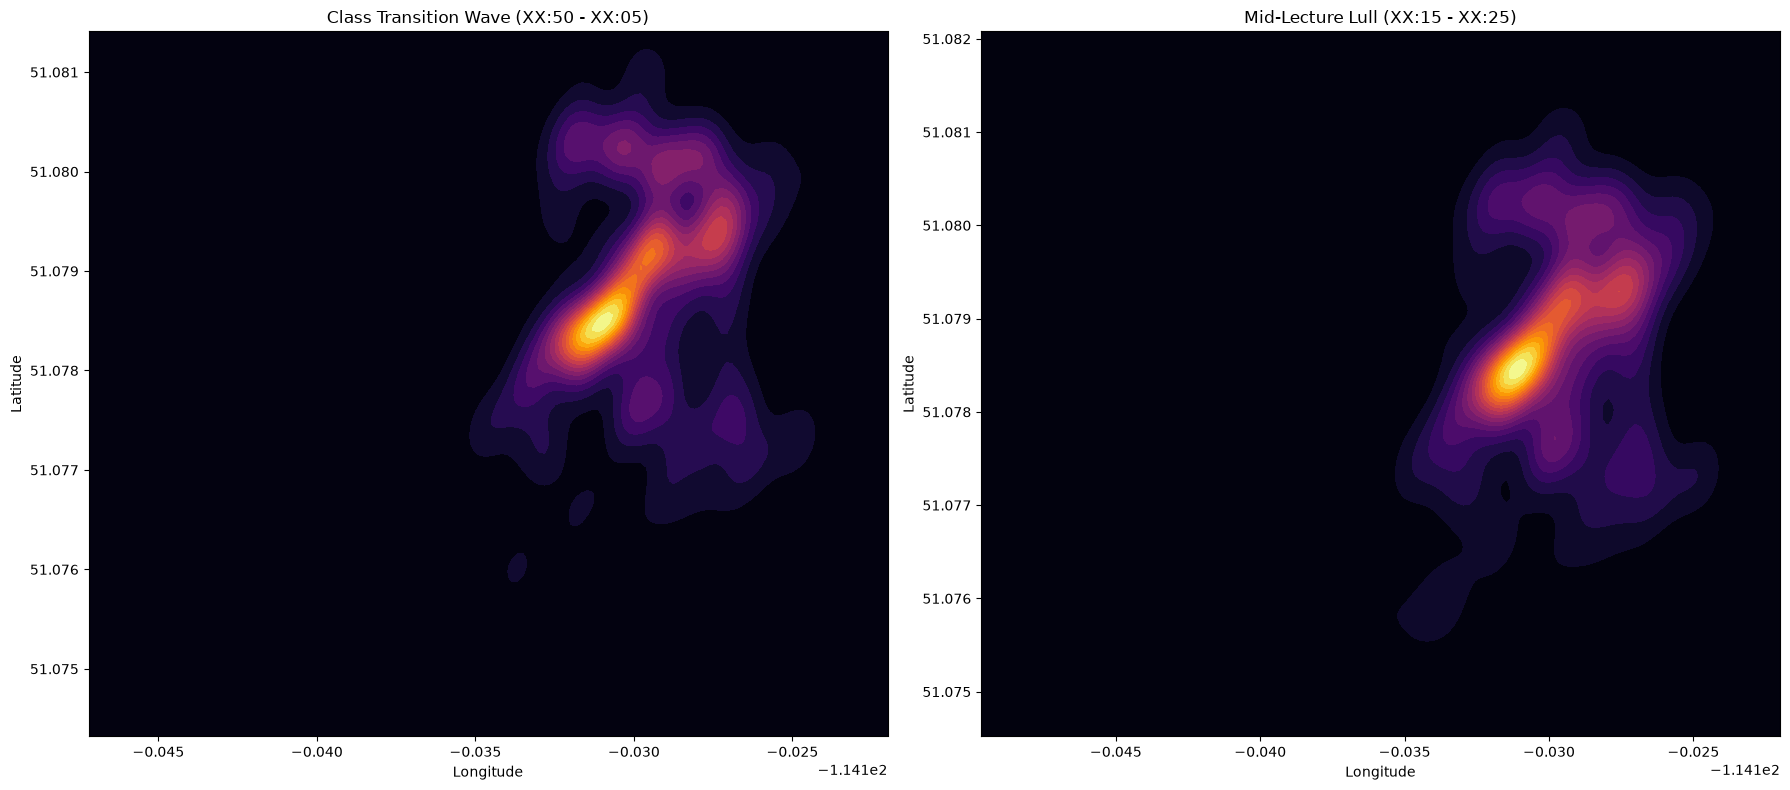

In [14]:
# Compare path density during a class transition (XX:50 - XX:00) vs mid-lecture (XX:15 - XX:25)
transition_wave = df_path[(df_path["minute"] >= 50) | (df_path["minute"] <= 5)]
mid_class_lull = df_path[(df_path["minute"] >= 15) & (df_path["minute"] <= 25)]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, data, title in zip(axes, [transition_wave, mid_class_lull], ["Class Transition Wave (XX:50 - XX:05)", "Mid-Lecture Lull (XX:15 - XX:25)"]):
    x, y = data["lon"].values, data["lat"].values
    kde = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[x.min():x.max():150j, y.min():y.max():150j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    
    ax.contourf(xi, yi, zi, levels=20, cmap="inferno")
    ax.set_title(title)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "od_schedule_waves.png"), dpi=300)
plt.show()